In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from brian2 import *
import functions as fc

In [3]:
simtime2 = 600*10**3 * ms

In [8]:
data_b = np.load('analysis_b.npz', allow_pickle=True)

In [9]:
SpikeMon_t = data_b['SpikeMon_t'] 
SpikeMon_i = data_b['SpikeMon_i'] 
RateMonE_t = data_b['RateMonE_t'] 
RateMonE_rate = data_b['RateMonE_rate'] 
SpikeTrains = data_b['SpikeTrainE'].item()
Current_t = data_b['Current_t'] 
Current_inh = data_b['Current_inh']
Current_exc = data_b['Current_exc']
SynMon_t = data_b['SynMon_t']
SynMon_w = data_b['SynMon_w']

In [10]:
cv_dist_start = fc.get_isi_cv(N=800, spike_trains=SpikeTrains, t_min=0*ms, t_max=100*ms)
mean_cv_start = np.mean(cv_dist_start)
cv_dist_end = fc.get_isi_cv(N=800, spike_trains=SpikeTrains, t_min=simtime2 - 1000*ms, t_max=simtime2)
mean_cv_end = np.mean(cv_dist_end)

In [11]:
corr_array_start = fc.get_spike_correlation(spike_trains=SpikeTrains, t_min=0, t_max=100, bin_size=2, N=800)
corr_array_end = fc.get_spike_correlation(spike_trains=SpikeTrains, t_min=(simtime2 - 1000*ms)/ms, t_max=simtime2/ms, bin_size=20, N=800)

In [12]:
mean_corr_start = np.mean(corr_array_start)
mean_corr_end = np.mean(corr_array_end)

In [13]:
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [14]:
mask_1 = SpikeMon_t <= 0.2
mask_3 = SpikeMon_t >= (simtime2 / second) - 0.2

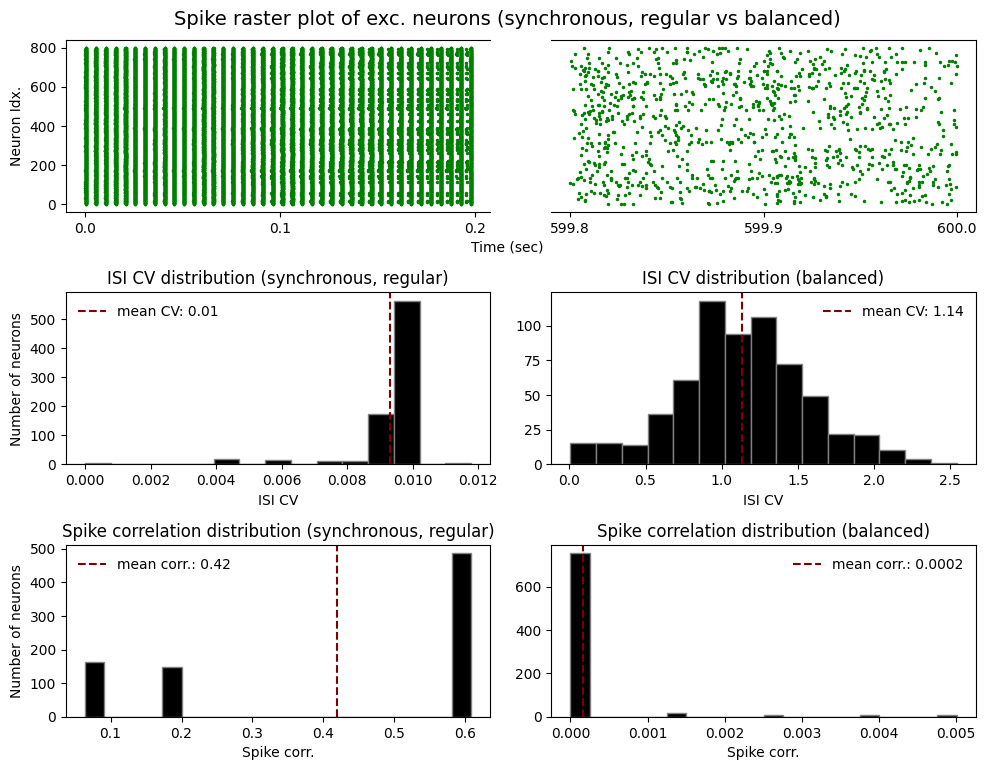

In [15]:
fig = plt.figure(figsize=(10, 7.5))
gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 1])  

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(SpikeMon_t[mask_1], SpikeMon_i[mask_1], '.g', ms=3)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel('Neuron Idx.')
ax1.set_xticks([0, 0.1, 0.2])

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(SpikeMon_t[mask_3], SpikeMon_i[mask_3], '.g', ms=3)
ax2.spines['left'].set_visible(False)
ax2.set_xticks([599.8, 599.9, 600])
ax2.set_yticks([])
ax2.ticklabel_format(style='plain', useOffset=False)

bbox1 = ax1.get_position()
bbox2 = ax2.get_position()

x_center = 0.5 * (bbox1.x0 + bbox2.x1)
y_bottom = min(bbox1.y0, bbox2.y0)
y_top = max(bbox1.y1, bbox2.y1)

fig.text(
    x_center,
    y_bottom + 0.06,
    'Time (sec)',
    ha='center',
    va='top'
)
fig.text(
    x_center,
    y_top + 0.115,
    'Spike raster plot of exc. neurons (synchronous, regular vs balanced)',
    ha='center',
    va='bottom',
    fontsize=14
)

ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(cv_dist_start, bins=15, color='black', edgecolor='grey', alpha=1)
ax3.axvline(mean_cv_start, color='maroon', ls='--', label=f'mean CV: {np.round(mean_cv_start, 2)}')
ax3.axhline(0, color='k', lw=0.8)
ax3.set_xlabel('ISI CV')
ax3.set_ylabel('Number of neurons')
ax3.legend(frameon=False)
ax3.set_title('ISI CV distribution (synchronous, regular)')

ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(cv_dist_end, bins=15, color='black', edgecolor='grey', alpha=1)
ax4.axvline(mean_cv_end, color='maroon', ls='--', label=f'mean CV: {np.round(mean_cv_end, 2)}')
ax4.axhline(0, color='k', lw=0.8)
ax4.set_xlabel('ISI CV')
ax4.legend(frameon=False)
ax4.set_title('ISI CV distribution (balanced)')

ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(corr_array_start, bins=20, color='black', edgecolor='grey', alpha=1)
ax5.axvline(mean_corr_start, color='maroon', ls='--', label=f'mean corr.: {np.round(mean_corr_start, 2)}')
ax5.axhline(0, color='k', lw=0.8)
ax5.set_xlabel('Spike corr.')
ax5.set_ylabel('Number of neurons')
ax5.legend(frameon=False)
ax5.set_title('Spike correlation distribution (synchronous, regular)')

ax6 = fig.add_subplot(gs[2, 1])
ax6.hist(corr_array_end, bins=20, color='black', edgecolor='grey', alpha=1)
ax6.axvline(mean_corr_end, color='maroon', ls='--', label=f'mean corr.: {np.round(mean_corr_end, 4)}')
ax6.axhline(0, color='k', lw=0.8)
ax6.set_xlabel('Spike corr.')
ax6.legend(frameon=False)
ax6.set_title('Spike correlation distribution (balanced)')


plt.savefig('./Plots/fig_1.png', format='png', dpi=300, bbox_inches="tight")
plt.savefig('./Plots/fig_1.pdf', format='pdf', dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

WARNING    /tmp/ipykernel_129931/3906627486.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
 [py.warnings]


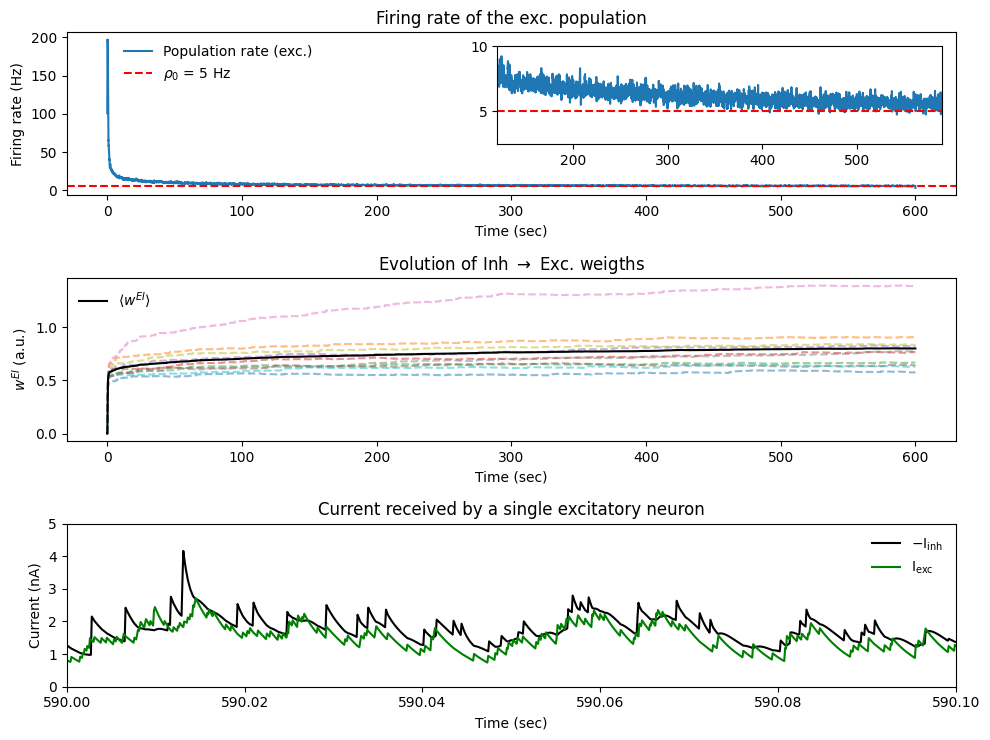

In [17]:
fig = plt.figure(figsize=(10, 7.5))
gs = GridSpec(3, 1, figure=fig, height_ratios=[1, 1, 1])  

ax1 = fig.add_subplot(gs[0])
ax1.plot(RateMonE_t, RateMonE_rate, label="Population rate (exc.)")
ax1.axhline(5, linestyle='--', color='red', label='$\\rho_{0}$ = 5 Hz')
ax1.set_ylabel('Firing rate (Hz)')
ax1.set_xlabel('Time (sec)')
axins = inset_axes(
    ax1,
    width="50%",    
    height="60%",
    loc="upper right",
    borderpad=1
)
ax1.legend(loc='upper left', bbox_to_anchor=(0.05, 1.0), frameon=False)
ax1.set_title('Firing rate of the exc. population')

axins.plot(RateMonE_t, RateMonE_rate)
axins.axhline(5, linestyle='--', color='red')
axins.set_ylim(2.5, 10)
axins.set_xticks([100, 200, 300, 400, 500])
axins.set_xlim([simtime2/second - 480, simtime2/second - 10])
axins.ticklabel_format(style='plain', useOffset=False)
axins.set_yticks([5, 10])

ax2 = fig.add_subplot(gs[1])
ax2.plot(SynMon_t, SynMon_w, alpha=0.5, ls='--')
ax2.plot(SynMon_t, np.mean(SynMon_w, axis=1), label="$\\langle w^{EI} \\rangle$", color='black')
ax2.legend(frameon=False, loc='upper left')
ax2.set_xlabel('Time (sec)')
ax2.set_ylabel('$w^{EI}$ (a.u.)')
ax2.set_title('Evolution of Inh $\\rightarrow$ Exc. weigths')

ax2 = fig.add_subplot(gs[2])
ax2.plot(Current_t, -Current_inh[0], color='black', label="$-\\text{I}_{\\text{inh}}$")
ax2.plot(Current_t, Current_exc[0], color='green', label="$\\text{I}_{\\text{exc}}$")
#ax2.plot(Current_t, Current_exc[0]+Current_inh[0], color='grey', label="$I_{exc} + I_{inh}$")
ax2.set_ylim([0, 5])
ax2.set_xlim([590, 590.1])
ax2.legend(frameon=False, loc='upper right')
ax2.set_title('Current received by a single excitatory neuron')
ax2.set_ylabel('Current (nA)')
ax2.set_xlabel('Time (sec)')

plt.savefig('./Plots/fig_2.png', format='png', dpi=300, bbox_inches="tight")
plt.savefig('./Plots/fig_2.pdf', format='pdf', dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()